In [1]:
!pip install -q torchmetrics iterative-stratification optuna shap
!pip install -q huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 44.0 MB/s eta 0:00:00


In [2]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

from datasets import load_dataset

pd.set_option("display.max_columns", 200)

root = "ADS599-Capstone/modeling_data"

df_patient = load_dataset(path=root, name='full_patient_state', split='full_patient_state').to_pandas()
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

README.md: 0.00B [00:00, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.67M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.72M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.63M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.52M [00:00<?, ?B/s]

...

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.69M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.62M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.70M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.57M [00:00<?, ?B/s]

Generating full_patient_state split:   0%|          | 0/6551723 [00:00<?, ? examples/s]

In [4]:
torch.manual_seed(10)
np.random.seed(10)
torch.cuda.manual_seed(10)
torch.cuda.manual_seed_all(10)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [66]:
# Keep only unique state rows per stay
drop_cols = df_patient.columns[4:].tolist()
drop_cols.remove("time_since_last_hrs")
drop_cols.append("ed_stay_id")
df_model = df_patient.drop_duplicates(subset=drop_cols).copy()

print(f"Original rows: {len(df_patient):,}")
print(f"Filtered rows: {len(df_model):,}")
print(f"Reduction:     {1 - len(df_model)/len(df_patient):.1%}")
print("Terminal event distribution:")
print(df_model.drop_duplicates("ed_stay_id")["terminal_event"].value_counts())


Original rows: 6,551,723
Filtered rows: 1,122,668
Reduction:     82.9%
Terminal event distribution:
terminal_event
DISCHARGE_ED      38130
DISCHARGE_WARD    27834
ICU               18247
Name: count, dtype: int64


# Preprocess and One-Hot-Encode Categorical Columns

In [67]:
# Map Gender
gender_map = {"F": 1, "M": 0}
df_model["gender"] = df_model["gender"].map(gender_map)

# Change acuity to integer
df_model["acuity"] = df_model["acuity"].astype(int)

# Mask height and weight
df_model["height_missing"] = df_model["height"].isna().astype(int)
df_model["weight_missing"] = df_model["weight"].isna().astype(int)
df_model[["height", "weight"]] = df_model[["height", "weight"]].fillna(0)

# Create pain_missing column and convert the Other category to 0
df_model["pain_missing"] = (df_model["current_pain"] == "Other").astype(int)
df_model["current_pain"] = pd.to_numeric(df_model["current_pain"], errors="coerce").fillna(0)

# Mask admission type then one hot encode admission and arrival
df_model["admission_missing"] = df_model["admission_type"].isna().astype(int)
at_dummies = pd.get_dummies(df_model["admission_type"], prefix="admission_type", dummy_na=False, dtype=int)
arrival_dummies = pd.get_dummies(df_model["arrival_transport"], prefix="arrival_transport", dtype=int)
df_model_updated = pd.concat([df_model, at_dummies, arrival_dummies], axis=1).drop(columns=["admission_type", "arrival_transport"])

# ── One-hot encode ordinal result columns ────────────────────────────────
# Lab, microbiology, ECG, and radiology columns are label-encoded integers
# that imply false ordinality (e.g. Not Ordered->Pending != Normal->Abnormal).
# OHE removes this: 'Not_Ordered' is dropped as the baseline category,
# implied when all dummies for that column are 0.

lab_cols = [
    'Chemistry-Blood', 'Hematology-Blood', 'Hematology-Urine', 'Blood Gas-Blood',
    'Chemistry-Urine', 'Chemistry-Other Body Fluid', 'Hematology-Cerebrospinal Fluid',
    'Chemistry-Cerebrospinal Fluid', 'Hematology-Ascites', 'Chemistry-Ascites',
    'Chemistry-Pleural', 'Hematology-Pleural', 'Hematology-Joint Fluid',
    'Chemistry-Stool', 'Hematology-Other Body Fluid', 'Blood Gas-Other Body Fluid',
    'Hematology-Bone Marrow', 'Hematology-Stool', 'Chemistry-Joint Fluid', 'URINE'
]
lab_map = {0: 'Not_Ordered', 1: 'Pending', 2: 'Normal', 3: 'Abnormal'}

micro_cols = [
    'Rapid Respiratory Viral Screen & Culture', 'PERITONEAL FLUID', 'BLOOD CULTURE',
    'STOOL', 'OTHER', 'PLEURAL FLUID', 'TISSUE', 'SEROLOGY/BLOOD', 'IMMUNOLOGY',
    'MRSA SCREEN', 'SWAB', 'JOINT FLUID', 'SPUTUM', 'FLUID,OTHER', 'ABSCESS',
    'BRONCHOALVEOLAR LAVAGE', 'CSF;SPINAL FLUID', 'Blood (CMV AB)', 'Blood (EBV)', 'BILE'
]
micro_map = {0: 'Not_Ordered', 1: 'Pending', 2: 'Negative', 3: 'Positive', 4: 'Other'}

status_cols = ['ecg_status', 'rad_status']
status_map  = {0: 'Not_Ordered', 1: 'Normal', 2: 'Moderate', 3: 'Acute'}

ohe_frames = [df_model_updated]

for col in lab_cols:
    mapped  = df_model_updated[col].map(lab_map).fillna('Not_Ordered')
    dummies = pd.get_dummies(mapped, prefix=col, dtype=int).reindex(
        columns=[f'{col}_Pending', f'{col}_Normal', f'{col}_Abnormal'], fill_value=0)
    ohe_frames.append(dummies)

for col in micro_cols:
    mapped  = df_model_updated[col].map(micro_map).fillna('Not_Ordered')
    dummies = pd.get_dummies(mapped, prefix=col, dtype=int).reindex(
        columns=[f'{col}_Pending', f'{col}_Negative', f'{col}_Positive', f'{col}_Other'], fill_value=0)
    ohe_frames.append(dummies)

for col in status_cols:
    mapped  = df_model_updated[col].map(status_map).fillna('Not_Ordered')
    dummies = pd.get_dummies(mapped, prefix=col, dtype=int).reindex(
        columns=[f'{col}_Normal', f'{col}_Moderate', f'{col}_Acute'], fill_value=0)
    ohe_frames.append(dummies)

df_model_updated = pd.concat(ohe_frames, axis=1).drop(
    columns=lab_cols + micro_cols + status_cols
)
print(f'df_model_updated shape after OHE: {df_model_updated.shape}')


df_model_updated shape after OHE: (1122668, 256)


# Isolate Columns

In [68]:
# Columns out of order so this pieces all the state cols together
vitals = [c for c in df_model_updated.loc[:, 'current_temperature':'dbp_rate'].columns
          if not c.endswith('_rate') and not c.endswith('_delta')]
med_cols = [c for c in df_model_updated.columns if c.startswith('recon')]
admission_cols = at_dummies.columns.to_list() + ['admission_missing']
arrival_cols = arrival_dummies.columns.to_list()
dispensed_meds = df_model_updated.columns[4:26].to_list()

# OHE result column groups (defined in lstm_preprocess)
lab_ohe_cols    = [c for c in df_model_updated.columns
                   if any(c.startswith(lc + '_') for lc in lab_cols)]
micro_ohe_cols  = [c for c in df_model_updated.columns
                   if any(c.startswith(mc + '_') for mc in micro_cols)]
status_ohe_cols = [c for c in df_model_updated.columns
                   if any(c.startswith(sc + '_') for sc in status_cols)]

# Definitive list of patient state cols
state_cols = (
    ['gender', 'anchor_age', 'acuity', 'height', 'height_missing',
     'weight_missing', 'pain_missing', 'weight', 'in_ed', 'in_ward']
    + dispensed_meds
    + med_cols
    + vitals
    + lab_ohe_cols
    + micro_ohe_cols
    + status_ohe_cols
    + admission_cols
    + arrival_cols
)

print(f'State cols: {len(state_cols)}')


State cols: 228


# Sequence Modeling

## Split Data

In [69]:
pad_length = df_model_updated.groupby('ed_stay_id').size().max()

# Encode terminal event: discharge=0, ICU=1
terminal_event_mapping = {"DISCHARGE_WARD": 0, "DISCHARGE_ED": 0, "ICU": 1}
df_model_updated["terminal_code"] = df_model_updated["terminal_event"].map(terminal_event_mapping)

valid_stays = df_model_updated.groupby("ed_stay_id").size()
valid_stays = valid_stays[valid_stays < pad_length].index
df_modeling = df_model_updated[df_model_updated["ed_stay_id"].isin(valid_stays)]
print(f"Stays after length filter: {df_modeling['ed_stay_id'].nunique():,}")


Stays after length filter: 84,210


This drop stays from the group that last less than 400 time steps.  Removes less than 1000 records from the group of 84k

In [70]:
def pad_stays(df, max_len=pad_length):
    grouped = df.groupby("ed_stay_id")
    states, labels, lengths = [], [], []

    for stay_id, group in grouped:
        s = group[state_cols].values.astype(np.float32)
        pad_len = max_len - len(s)
        s = np.pad(s, ((0, pad_len), (0, 0)))  # pad rows, not features
        label = int(group["terminal_code"].iloc[0])  # single label per stay
        states.append(s)
        labels.append(label)
        lengths.append(len(group))

    return np.stack(states), np.array(labels, dtype=np.int64), np.array(lengths)


In [10]:
stay_labels = (
    df_modeling.drop_duplicates("ed_stay_id")[["ed_stay_id", "terminal_code"]]
    .reset_index(drop=True)
)

train_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=10)
train_idx, test_idx = next(train_split.split(stay_labels, stay_labels["terminal_code"]))

train_stays = set(stay_labels.iloc[train_idx]["ed_stay_id"])
test_stays  = set(stay_labels.iloc[test_idx]["ed_stay_id"])

df_train = df_modeling[df_modeling["ed_stay_id"].isin(train_stays)].copy()
df_test  = df_modeling[df_modeling["ed_stay_id"].isin(test_stays)].copy()

print(f"Train stays: {df_train['ed_stay_id'].nunique():,}")
print(df_train.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nTest stays:  {df_test['ed_stay_id'].nunique():,}")
print(df_test.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nOverlap: {train_stays.intersection(test_stays)}")


Train stays: 67,368
terminal_event
DISCHARGE_ED      30513
DISCHARGE_WARD    22258
ICU               14597
Name: count, dtype: int64

Test stays:  16,842
terminal_event
DISCHARGE_ED      7617
DISCHARGE_WARD    5576
ICU               3649
Name: count, dtype: int64

Overlap: set()


## Scale and Pad Data

In [25]:
scale = StandardScaler()
scaling_cols = vitals + ['anchor_age', 'weight', 'height', 'time_since_last_hrs']

df_train[scaling_cols] = scale.fit_transform(df_train[scaling_cols])
df_test[scaling_cols] = scale.transform(df_test[scaling_cols])

In [26]:
missing = [c for c in state_cols if c not in df_train.columns]
extra = [c for c in df_train.columns if c not in state_cols + ["ed_stay_id", "subject_id", "hadm_id", "time", "terminal_event", "terminal_code", "ed_boarding"]]
print(f"In state_cols but not in df_train: {missing}")
print(f"In df_train but not accounted for: {extra}")

In state_cols but not in df_train: []
In df_train but not accounted for: ['temperature_delta', 'temperature_rate', 'heartrate_delta', 'heartrate_rate', 'resprate_delta', 'resprate_rate', 'o2sat_delta', 'o2sat_rate', 'sbp_delta', 'sbp_rate', 'dbp_delta', 'dbp_rate', 'observe', 'dispense_meds', 'ward_transfer', 'discharge', 'transfer_icu', 'ecg_ordered', 'rad_ordered', 'vitals_checked', 'labs_ordered', 'micro_ordered']


In [27]:
df_train.drop(columns=extra, inplace=True)
df_test.drop(columns=extra, inplace=True)

In [71]:
# Configurations
batch_size = 16
input_size = len(state_cols)  # set dynamically after OHE
hidden_size = 256
num_layers = 2
dropout = 0.2
num_classes = 2   # discharge=0, ICU=1
epochs = 5
print(f'input_size: {input_size}')

input_size: 228


In [ ]:
# Prep train
s_train, y_train, train_len = pad_stays(df_train)
s_train   = torch.tensor(s_train)
y_train   = torch.tensor(y_train)   # (N,) int64
train_len = torch.tensor(train_len)

# Prep test
s_test, y_test, test_len = pad_stays(df_test)
s_test = torch.tensor(s_test)
y_test = torch.tensor(y_test)
test_len = torch.tensor(test_len)

train_loader = DataLoader(
    TensorDataset(s_train, y_train, train_len),
    batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(10),
)
test_loader = DataLoader(
    TensorDataset(s_test, y_test, test_len),
    batch_size=batch_size, shuffle=False,
)

print(f"State dim:   {s_train.shape[2]}")
print(f"Train stays: {s_train.shape[0]:,}")
print(f"Test stays:  {s_test.shape[0]:,}")
print(f"Train class: discharge={(y_train==0).sum():,}  icu={(y_train==1).sum():,}")
print(f"Test  class: discharge={(y_test==0).sum():,}  icu={(y_test==1).sum():,}")


State dim:   228
Train stays: 67,368
Test stays:  16,842
Train class: discharge=52,771  icu=14,597
Test  class: discharge=13,193  icu=3,649


# Modeling Set Up

In [11]:
class SequenceModeling(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        last_hidden = h_n[-1]  # (B, hidden_size) top layer final hidden state
        return self.fc(last_hidden)  # (B, num_classes) logits

seq_model = SequenceModeling().to(device)
print(seq_model)


SequenceModeling(
  (lstm): LSTM(228, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [31]:
# Class weight to handle ICU minority class
stay_labels_train = df_train.drop_duplicates("ed_stay_id")["terminal_code"].values
labels_all = torch.tensor(stay_labels_train)
n_discharge = (labels_all == 0).sum().float()
n_icu = (labels_all == 1).sum().float()
class_weight = torch.tensor([1.0, (n_discharge / n_icu).item()]).to(device)
print(f"Class weights: discharge={class_weight[0]:.2f}  icu={class_weight[1]:.2f}")

learning_rate = 1e-4
loss_fn = nn.CrossEntropyLoss(weight=class_weight)
optimizer = torch.optim.AdamW(seq_model.parameters(), lr=learning_rate)

Class weights: discharge=1.00  icu=3.62


## Training Loop

In [20]:
from torchmetrics.classification import MulticlassF1Score
f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
f1_per_class = MulticlassF1Score(num_classes=num_classes, average="none")

In [21]:
def training_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y, lengths) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X, lengths)  # (B, 2) logits
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch % 200 == 0:
            current = batch * batch_size + len(X)
            print(f"loss: {loss.item():>7.4f} [{current:>5d}/{size:>5d}]")
    return total_loss / len(dataloader)

In [22]:
def evaluation_loop(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    test_loss = 0
    preds, true_y = [], []

    model.eval()
    with torch.no_grad():
        for X, y, lengths in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X, lengths)  # (B, 2) logits
            test_loss += loss_fn(pred, y).item()
            preds.append(torch.softmax(pred, dim=-1).cpu())
            true_y.append(y.cpu())

    final_preds = torch.cat(preds, dim=0)   # (N, 2) probs
    true_labels = torch.cat(true_y, dim=0)  # (N,) int64

    test_loss /= num_batches
    f1_macro = f1(final_preds, true_labels).item()
    f1_per = f1_per_class(final_preds, true_labels)
    print(f"\nAvg Loss: {test_loss:.4f}  F1_Macro: {f1_macro:.4f}")
    for cls, score in zip(["discharge", "icu"], f1_per.tolist()):
        print(f"  {cls}: {score:.4f}")

    return final_preds, true_labels, test_loss

In [ ]:
import os, tempfile
from huggingface_hub import HfApi

train_losses = []
eval_losses  = []

# Early stopping config
patience = 3
best_eval_loss = float("inf")
epochs_no_improve = 0
best_model_state = None
best_epoch = 0
hf_repo_id = "ADS599-Capstone/ohe_lstm_model"
hf_filename = "lstm_one_hot_model_best.pt"

hf_api = HfApi()
hf_api.create_repo(hf_repo_id, exist_ok=True, private=True)

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}------------------------------")
    t_loss = training_loop(train_loader, seq_model, loss_fn, optimizer)
    train_losses.append(t_loss)
    final_preds, true_labels, e_loss = evaluation_loop(test_loader, seq_model, loss_fn)
    eval_losses.append(e_loss)

    if e_loss < best_eval_loss:
        best_eval_loss = e_loss
        best_epoch = epoch + 1
        best_model_state = {k: v.clone() for k, v in seq_model.state_dict().items()}
        epochs_no_improve = 0
        # Save to HuggingFace Hub
        with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as tmp:
            torch.save(best_model_state, tmp.name)
            tmp_path = tmp.name
        hf_api.upload_file(
            path_or_fileobj=tmp_path,
            path_in_repo=hf_filename,
            repo_id=hf_repo_id,
        )
        os.unlink(tmp_path)
        print(f"  ** New best eval loss: {best_eval_loss:.4f} (saved to {hf_repo_id}/{hf_filename})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{patience} epochs")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1}. Best was epoch {best_epoch}.")
            break

# Restore best model
if best_model_state is not None:
    seq_model.load_state_dict(best_model_state)
    print(f"\nRestored model from epoch {best_epoch} (eval loss: {best_eval_loss:.4f})")
    final_preds, true_labels, _ = evaluation_loop(test_loader, seq_model, loss_fn)


# Hyperparameter Tuning

In [57]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def build_model(hs, nl, dr):
    class _Model(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hs,
                                num_layers=nl, batch_first=True,
                                dropout=dr if nl > 1 else 0.0)
            self.fc = nn.Linear(hs, num_classes)
        def forward(self, x, lengths):
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            _, (h_n, _) = self.lstm(packed)
            return self.fc(h_n[-1])
    return _Model().to(device)

def objective(trial):
    hs = trial.suggest_categorical('hidden_size', [128, 256, 512])
    nl = trial.suggest_int('num_layers', 1, 3)
    dr = trial.suggest_float('dropout', 0.1, 0.4)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [16, 32, 64])

    model = build_model(hs, nl, dr)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr)

    loader_tr = DataLoader(TensorDataset(s_train, y_train, train_len), batch_size=bs, shuffle=True,
                       generator=torch.Generator().manual_seed(42))
    loader_te = DataLoader(TensorDataset(s_test,  y_test,  test_len),  batch_size=bs, shuffle=False)

    best_loss = float('inf')
    patience_t, no_improve = 3, 0

    for epoch in range(10):
        training_loop(loader_tr, model, loss_fn, opt)
        _, _, e_loss = evaluation_loop(loader_te, model, loss_fn)

        trial.report(e_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if e_loss < best_loss:
            best_loss = e_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_t:
                break

    return best_loss


In [58]:
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print('Best trial:')
print(f'  Eval loss: {study.best_value:.4f}')
print(f'  Params:    {study.best_params}')

  0%|          | 0/20 [00:00<?, ?it/s]

loss:  0.6954 [   32/67368]
loss:  0.4753 [ 3232/67368]
loss:  0.4204 [ 6432/67368]
loss:  0.4781 [ 9632/67368]
loss:  0.6946 [12832/67368]
loss:  0.4710 [16032/67368]
loss:  0.3771 [19232/67368]
loss:  0.3113 [22432/67368]
loss:  0.2015 [25632/67368]
loss:  0.1127 [28832/67368]
loss:  0.3444 [32032/67368]

Avg Loss: 0.2677  F1_Macro: 0.8385
  discharge: 0.9167
  icu: 0.7603
loss:  0.3667 [   32/67368]
loss:  0.2766 [ 3232/67368]
loss:  0.2258 [ 6432/67368]
loss:  0.2358 [ 9632/67368]
loss:  0.2190 [12832/67368]
loss:  0.2638 [16032/67368]
loss:  0.2103 [19232/67368]
loss:  0.3361 [22432/67368]
loss:  0.5556 [25632/67368]
loss:  0.0844 [28832/67368]
loss:  0.1075 [32032/67368]

Avg Loss: 0.1973  F1_Macro: 0.9036
  discharge: 0.9568
  icu: 0.8504
loss:  0.2016 [   32/67368]
loss:  0.1281 [ 3232/67368]
loss:  0.2680 [ 6432/67368]
loss:  0.0933 [ 9632/67368]
loss:  0.0904 [12832/67368]
loss:  0.1270 [16032/67368]
loss:  0.1250 [19232/67368]
loss:  0.1842 [22432/67368]
loss:  0.1214 [25632

In [ ]:
# Retrain with best hyperparameters from Optuna
bp = study.best_params
best_hs = bp['hidden_size']
best_nl = bp['num_layers']
best_dr = bp['dropout']
best_lr = bp['lr']
best_bs = bp['batch_size']

print(f'Retraining with: hidden={best_hs}  layers={best_nl}  dropout={best_dr:.3f}  lr={best_lr:.2e}  batch={best_bs}')

seq_model = build_model(best_hs, best_nl, best_dr)
optimizer = torch.optim.AdamW(seq_model.parameters(), lr=best_lr)
train_loader = DataLoader(TensorDataset(s_train, y_train, train_len), batch_size=best_bs, shuffle=True)
test_loader  = DataLoader(TensorDataset(s_test,  y_test,  test_len),  batch_size=best_bs, shuffle=False)

# Re-run the epoch loop cell (66801b6c) to train with early stopping

Retraining with: hidden=512  layers=2  dropout=0.269  lr=1.90e-04  batch=16


# Evaluation

shap_values is an array of shape: (200, 99, 228, 2)


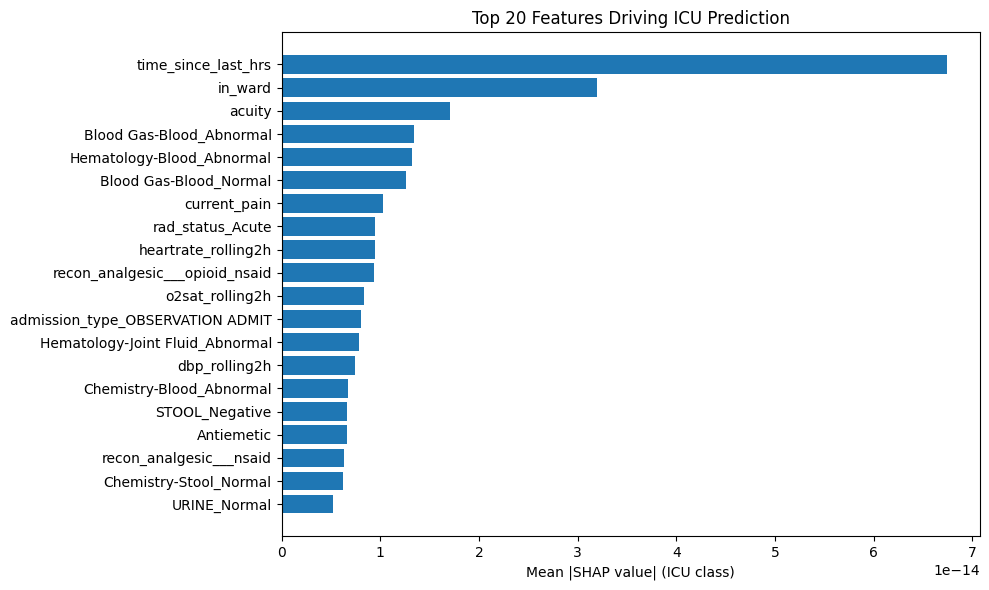

In [ ]:
import shap

# GradientExplainer requires training mode for cuDNN RNN gradient computation
seq_model.train()

# Background: 200 random training samples
bg_idx = torch.randperm(s_train.shape[0], generator=torch.Generator().manual_seed(10))[:200]
bg_data = s_train[bg_idx].to(device)

class ModelWrapper(nn.Module):
    def forward(self, x):
        lengths = torch.full((x.shape[0],), x.shape[1], dtype=torch.long)
        packed  = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = seq_model.lstm(packed)
        return seq_model.fc(h_n[-1])

wrapper = ModelWrapper().to(device)

n_explain = 200
exp_idx   = torch.randperm(s_test.shape[0], generator=torch.Generator().manual_seed(10))[:n_explain]
exp_data  = s_test[exp_idx].to(device)

explainer   = shap.GradientExplainer(wrapper, bg_data)
shap_values = explainer.shap_values(exp_data)

seq_model.eval()

# Inspect structure
if isinstance(shap_values, list):
    print(f'shap_values is a list of {len(shap_values)} arrays')
    for i, sv in enumerate(shap_values):
        print(f'  [{i}] shape: {np.array(sv).shape}')
    # ICU class = index 1 if 2 elements, else last axis
    shap_icu_raw = np.array(shap_values[1])
else:
    shap_values = np.array(shap_values)
    print(f'shap_values is an array of shape: {shap_values.shape}')
    # Newer shap: shape (n_explain, T, 124, 2) — take ICU class (axis -1, index 1)
    shap_icu_raw = shap_values[..., 1]

# Aggregate: mean |SHAP| across timesteps then samples -> (124,)
mean_shap = np.abs(shap_icu_raw).mean(axis=1).mean(axis=0)  # (124,)

# Plot top 20 features
top_idx   = np.argsort(mean_shap)[::-1][:20]
top_vals  = mean_shap[top_idx]
top_names = [state_cols[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_names[::-1], top_vals[::-1])
ax.set_xlabel('Mean |SHAP value| (ICU class)')
ax.set_title('Top 20 Features Driving ICU Prediction')
plt.tight_layout()
plt.show()


In [37]:
predicted_classes = final_preds.argmax(dim=1)
print(f"Predicted discharge: {(predicted_classes==0).sum():,} ({(predicted_classes==0).float().mean():.2%})")
print(f"Predicted ICU:       {(predicted_classes==1).sum():,} ({(predicted_classes==1).float().mean():.2%})")
print(f"\nTrue discharge: {(true_labels==0).sum():,} ({(true_labels==0).float().mean():.2%})")
print(f"True ICU:       {(true_labels==1).sum():,} ({(true_labels==1).float().mean():.2%})")


Predicted discharge: 12,940 (76.83%)
Predicted ICU:       3,902 (23.17%)

True discharge: 13,193 (78.33%)
True ICU:       3,649 (21.67%)


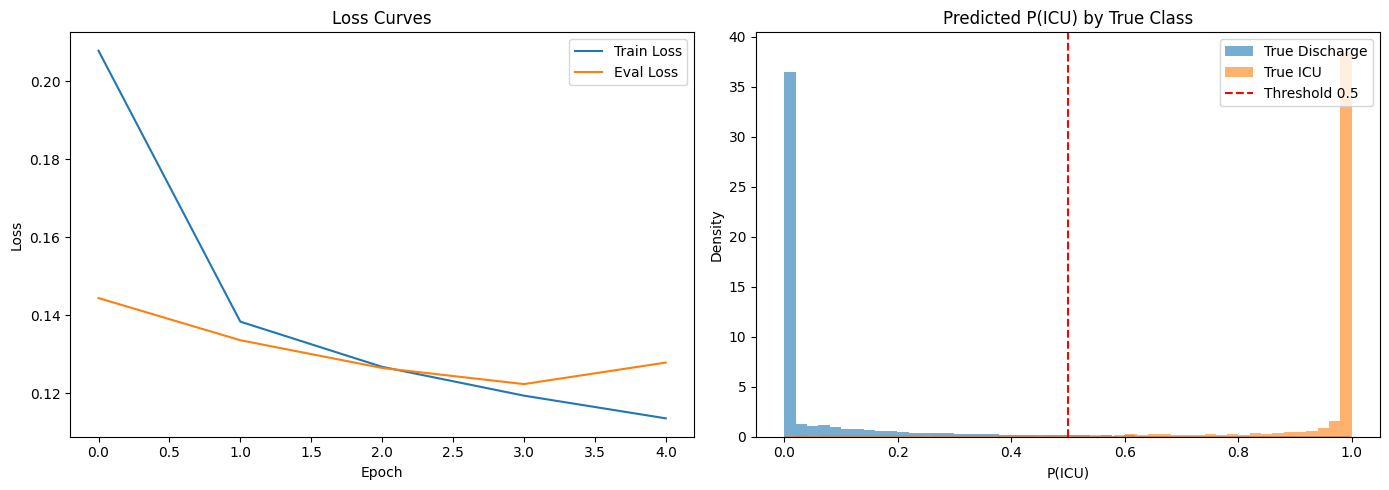

In [38]:
pred_probs = final_preds.numpy()  # (N, 2)
true_np = true_labels.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(eval_losses, label="Eval Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].hist(pred_probs[true_np==0, 1], bins=50, alpha=0.6, label="True Discharge", density=True)
axes[1].hist(pred_probs[true_np==1, 1], bins=50, alpha=0.6, label="True ICU", density=True)
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="Threshold 0.5")
axes[1].set_title("Predicted P(ICU) by True Class")
axes[1].set_xlabel("P(ICU)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


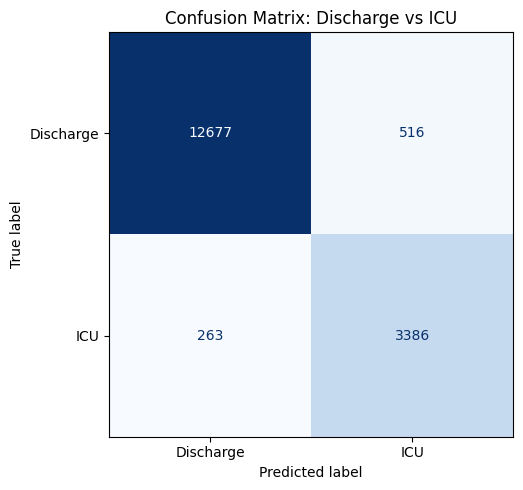

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predicted_classes = final_preds.argmax(dim=1).numpy()
true_np = true_labels.numpy()

cm = confusion_matrix(true_np, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Discharge", "ICU"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix: Discharge vs ICU")
plt.tight_layout()
plt.show()


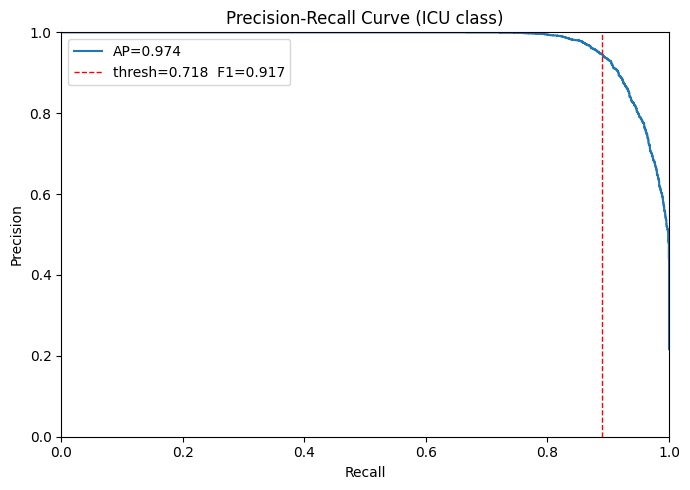

Optimal threshold: 0.7182
F1 at optimal:     0.9172
Average Precision: 0.9744


In [40]:
from sklearn.metrics import precision_recall_curve, average_precision_score

pred_np = final_preds.numpy()
true_np = true_labels.numpy()

prec, rec, thresh = precision_recall_curve(true_np, pred_np[:, 1])
ap = average_precision_score(true_np, pred_np[:, 1])
f1s = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = f1s.argmax()
optimal_threshold = float(thresh[best_idx])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, lw=1.5, label=f"AP={ap:.3f}")
ax.axvline(rec[best_idx], color="red", linestyle="--", linewidth=1,
           label=f"thresh={optimal_threshold:.3f}  F1={f1s[best_idx]:.3f}")
ax.set_title("Precision-Recall Curve (ICU class)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"F1 at optimal:     {f1s[best_idx]:.4f}")
print(f"Average Precision: {ap:.4f}")


In [42]:
len(pred_probs)

16842

# Step by Step

Train a fresh LSTM on 60% of the data, then run per-timestep inference on the remaining 40%.
The 40% split (with P(ICU) at every timestep appended) becomes the RL agent's training dataset.
Using a separate split prevents the confidence signal from leaking information the RL agent should not have.

In [72]:
sbs_labels = (
    df_modeling.drop_duplicates('ed_stay_id')[['ed_stay_id', 'terminal_code']]
    .reset_index(drop=True)
)

sbs_split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=10)
sbs_train_idx, sbs_infer_idx = next(sbs_split.split(sbs_labels, sbs_labels['terminal_code']))

sbs_train_stays = set(sbs_labels.iloc[sbs_train_idx]['ed_stay_id'])
sbs_infer_stays = set(sbs_labels.iloc[sbs_infer_idx]['ed_stay_id'])

df_sbs_train = df_modeling[df_modeling['ed_stay_id'].isin(sbs_train_stays)].copy()
df_sbs_infer = df_modeling[df_modeling['ed_stay_id'].isin(sbs_infer_stays)].copy()

print(f"SbS train stays: {df_sbs_train['ed_stay_id'].nunique():,}")
print(df_sbs_train.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nSbS infer stays: {df_sbs_infer['ed_stay_id'].nunique():,}")
print(df_sbs_infer.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nOverlap: {sbs_train_stays.intersection(sbs_infer_stays)}")


SbS train stays: 50,526
terminal_event
DISCHARGE_ED      22919
DISCHARGE_WARD    16659
ICU               10948
Name: count, dtype: int64

SbS infer stays: 33,684
terminal_event
DISCHARGE_ED      15211
DISCHARGE_WARD    11175
ICU                7298
Name: count, dtype: int64

Overlap: set()


In [73]:
from sklearn.preprocessing import StandardScaler

scaling_cols = vitals + ['anchor_age', 'weight', 'height', 'time_since_last_hrs']
sbs_scaler = StandardScaler()
df_sbs_train[scaling_cols] = sbs_scaler.fit_transform(df_sbs_train[scaling_cols])
df_sbs_infer[scaling_cols] = sbs_scaler.transform(df_sbs_infer[scaling_cols])

# Drop columns not in state_cols (e.g. OHE intermediate cols, identifiers)
keep_cols = state_cols + ['ed_stay_id', 'terminal_code', 'terminal_event']
extra_train = [c for c in df_sbs_train.columns if c not in keep_cols]
extra_infer = [c for c in df_sbs_infer.columns if c not in keep_cols]
df_sbs_train = df_sbs_train.drop(columns=extra_train)
df_sbs_infer = df_sbs_infer.drop(columns=extra_infer)

print(f"SbS train scaled. Shape: {df_sbs_train.shape}")
print(f"SbS infer scaled. Shape: {df_sbs_infer.shape}")


SbS train scaled. Shape: (673832, 231)
SbS infer scaled. Shape: (448737, 231)


In [74]:
# Several ICU transfers were flipping to high prob of transfer once sent to ward so dropping location columns
state_cols.remove('in_ed')
state_cols.remove('in_ward')

In [ ]:
# Started overly relying on admission columns for predictions once the location columns were removed so also removed those
state_cols = [c for c in state_cols if c not in admission_cols]

In [111]:
s_sbs_train, y_sbs_train, sbs_train_len = pad_stays(df_sbs_train)
s_sbs_train = torch.tensor(s_sbs_train)
y_sbs_train = torch.tensor(y_sbs_train)
sbs_train_len = torch.tensor(sbs_train_len)

s_sbs_infer, y_sbs_infer, sbs_infer_len = pad_stays(df_sbs_infer)
s_sbs_infer = torch.tensor(s_sbs_infer)
y_sbs_infer = torch.tensor(y_sbs_infer)
sbs_infer_len = torch.tensor(sbs_infer_len)

sbs_train_loader = DataLoader(
    TensorDataset(s_sbs_train, y_sbs_train, sbs_train_len),
    batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(10),
)
sbs_infer_loader = DataLoader(
    TensorDataset(s_sbs_infer, y_sbs_infer, sbs_infer_len),
    batch_size=batch_size, shuffle=False,
)

print(f"SbS train stays: {s_sbs_train.shape[0]:,}  |  infer stays: {s_sbs_infer.shape[0]:,}")
print(f"State dim: {s_sbs_train.shape[2]}")
print(f"Train class: discharge={(y_sbs_train==0).sum():,}  icu={(y_sbs_train==1).sum():,}")
print(f"Infer class: discharge={(y_sbs_infer==0).sum():,}  icu={(y_sbs_infer==1).sum():,}")


SbS train stays: 50,526  |  infer stays: 33,684
State dim: 216
Train class: discharge=39,578  icu=10,948
Infer class: discharge=26,386  icu=7,298


In [114]:
from huggingface_hub import PyTorchModelHubMixin

input_size = 216 # updating to reflect removal of in_ed and in_ward

class SbsSequenceModeling(nn.Module, PyTorchModelHubMixin):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return self.fc(h_n[-1])  # (B, num_classes)

sbs_model = SbsSequenceModeling().to(device)

# Class weight for ICU minority - recomputed from the 60% split
sbs_n_discharge = (y_sbs_train == 0).sum().float()
sbs_n_icu = (y_sbs_train == 1).sum().float()
sbs_class_weight = torch.tensor([1.0, (sbs_n_discharge / sbs_n_icu).item()]).to(device)
sbs_loss_fn = nn.CrossEntropyLoss(weight=sbs_class_weight)
sbs_optimizer = torch.optim.AdamW(sbs_model.parameters(), lr=1e-4)

print(f"SbS class weights: discharge={sbs_class_weight[0]:.2f}  icu={sbs_class_weight[1]:.2f}")
print(sbs_model)


SbS class weights: discharge=1.00  icu=3.62
SbsSequenceModeling(
  (lstm): LSTM(216, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)



Epoch 1------------------------------
loss:  0.6960 [   16/50526]
loss:  0.3489 [ 3216/50526]
loss:  0.2941 [ 6416/50526]
loss:  0.3701 [ 9616/50526]
loss:  0.2942 [12816/50526]
loss:  0.2688 [16016/50526]
loss:  0.2984 [19216/50526]
loss:  0.3885 [22416/50526]
loss:  0.3490 [25616/50526]
loss:  0.2076 [28816/50526]
loss:  0.2506 [32016/50526]
loss:  0.5493 [35216/50526]
loss:  0.0983 [38416/50526]
loss:  0.1940 [41616/50526]
loss:  0.2397 [44816/50526]
loss:  0.6116 [48016/50526]

Avg Loss: 0.3002  F1_Macro: 0.8426
  discharge: 0.9257
  icu: 0.7595
  ** New best: 0.3002

Epoch 2------------------------------
loss:  0.2300 [   16/50526]
loss:  0.2994 [ 3216/50526]
loss:  0.3142 [ 6416/50526]
loss:  0.3927 [ 9616/50526]
loss:  0.0853 [12816/50526]
loss:  0.2580 [16016/50526]
loss:  0.3185 [19216/50526]
loss:  0.2537 [22416/50526]
loss:  0.1399 [25616/50526]
loss:  0.0563 [28816/50526]
loss:  0.2449 [32016/50526]
loss:  0.0876 [35216/50526]
loss:  0.1980 [38416/50526]
loss:  0.2458 [416

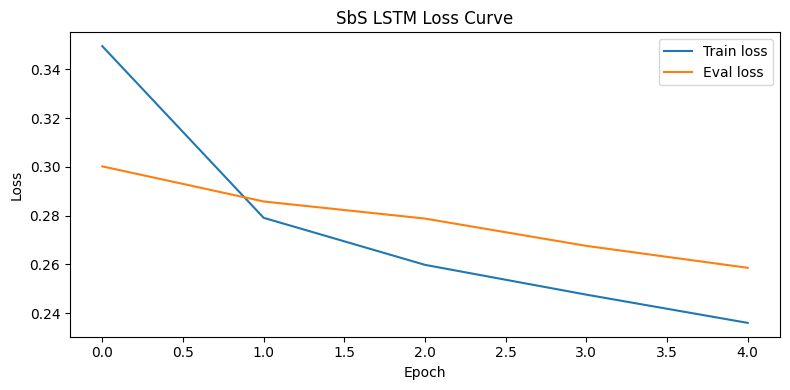

In [115]:
sbs_patience = 3
sbs_best_loss = float('inf')
sbs_no_improve = 0
sbs_best_state = None
sbs_best_epoch = 0
sbs_train_losses = []
sbs_eval_losses = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}------------------------------")
    t_loss = training_loop(sbs_train_loader, sbs_model, sbs_loss_fn, sbs_optimizer)
    sbs_train_losses.append(t_loss)
    _, _, e_loss = evaluation_loop(sbs_infer_loader, sbs_model, sbs_loss_fn)
    sbs_eval_losses.append(e_loss)

    if e_loss < sbs_best_loss:
        sbs_best_loss = e_loss
        sbs_best_epoch = epoch + 1
        sbs_best_state = {k: v.clone() for k, v in sbs_model.state_dict().items()}
        sbs_no_improve = 0
        print(f"  ** New best: {sbs_best_loss:.4f}")
    else:
        sbs_no_improve += 1
        print(f"  No improvement {sbs_no_improve}/{sbs_patience}")
        if sbs_no_improve >= sbs_patience:
            print(f"Early stopping at epoch {epoch + 1}. Best epoch: {sbs_best_epoch}")
            break

sbs_model.load_state_dict(sbs_best_state)
print(f"\nRestored SbS model from epoch {sbs_best_epoch} (loss: {sbs_best_loss:.4f})")

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sbs_train_losses, label='Train loss')
ax.plot(sbs_eval_losses,  label='Eval loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('SbS LSTM Loss Curve')
ax.legend(); plt.tight_layout(); plt.show()


In [116]:
class StepwiseWrapper(nn.Module):
    """Wraps the final-hidden-state LSTM to expose per-timestep softmax probabilities."""
    def __init__(self, base_model):
        super().__init__()
        self.lstm = base_model.lstm
        self.fc = base_model.fc

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        output, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(output, batch_first=True)  # (B, T_max, hidden)
        return self.fc(output)  # (B, T_max, 2) logits at every timestep

sbs_step_model = StepwiseWrapper(sbs_model).to(device)
sbs_step_model.eval()

sbs_seq_probs_list = []
sbs_lengths_list = []
sbs_true_list = []
sbs_pad_length = s_sbs_infer.shape[1]

with torch.no_grad():
    for X, y, lengths in sbs_infer_loader:
        X = X.to(device)
        logits = sbs_step_model(X, lengths)              # (B, T_max, 2)
        seq_probs = torch.softmax(logits, dim=-1).cpu()  # (B, T_max, 2)
        pad_needed = sbs_pad_length - seq_probs.shape[1]
        if pad_needed > 0:
            seq_probs = torch.nn.functional.pad(seq_probs, (0, 0, 0, pad_needed))
        sbs_seq_probs_list.append(seq_probs)
        sbs_lengths_list.append(lengths)
        sbs_true_list.append(y)

sbs_seq_probs_all = torch.cat(sbs_seq_probs_list, dim=0)  # (N, pad_length, 2)
sbs_lengths_all = torch.cat(sbs_lengths_list, dim=0)      # (N,)
sbs_true_labels = torch.cat(sbs_true_list, dim=0)         # (N,)

print(f"seq_probs_all shape: {sbs_seq_probs_all.shape}")
print(f"lengths_all shape:   {sbs_lengths_all.shape}")


seq_probs_all shape: torch.Size([33684, 99, 2])
lengths_all shape:   torch.Size([33684])


/tmp/ipykernel_953/3965756500.py:11: RuntimeWarning: Mean of empty slice
  mean_dis = np.nanmean(picu_mat[discharge_mask], axis=0)
/tmp/ipykernel_953/3965756500.py:12: RuntimeWarning: Mean of empty slice
  mean_icu = np.nanmean(picu_mat[icu_mask], axis=0)


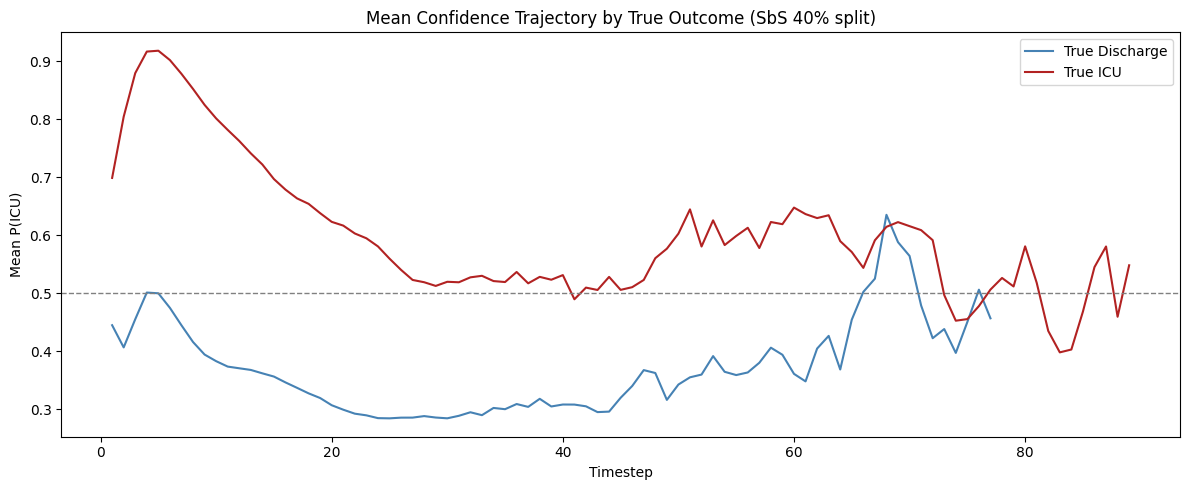

/tmp/ipykernel_953/3965756500.py:34: RuntimeWarning: Mean of empty slice
  mean_t = np.nanmean(picu_mat[m], axis=0)


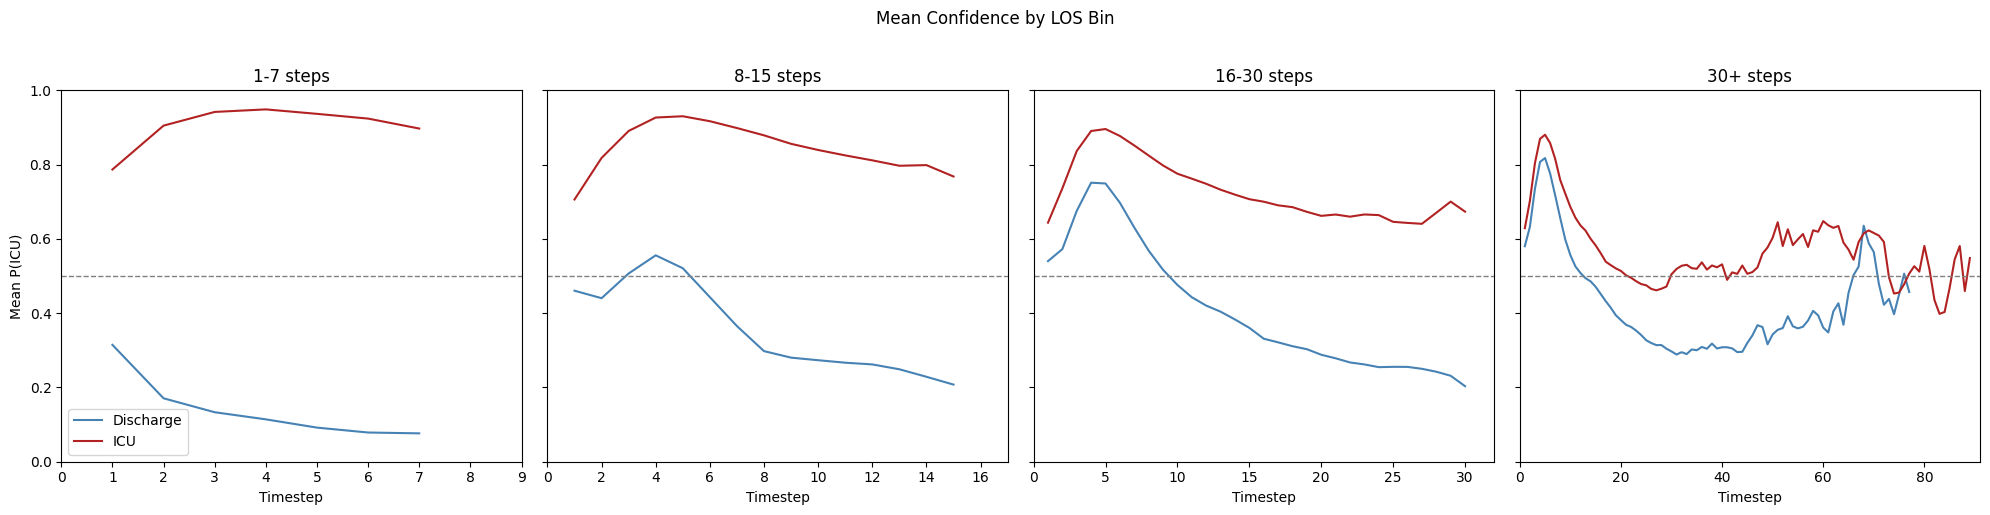

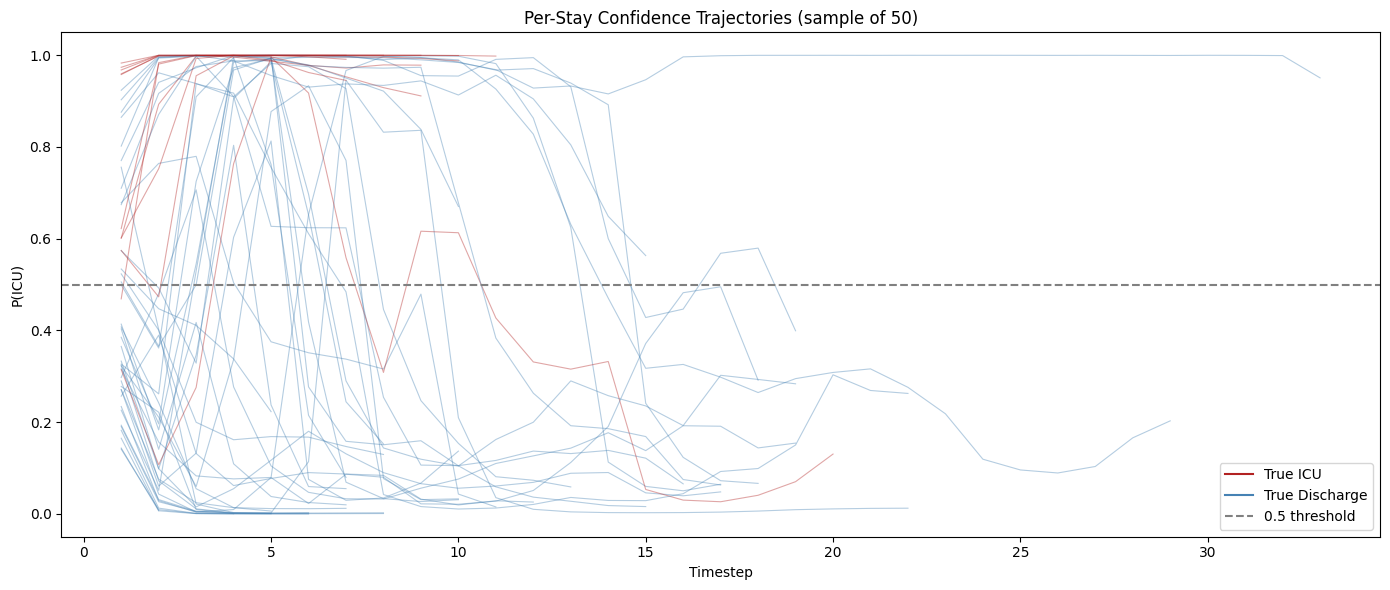

Confidence switchers: 19742 / 33684 stays (58.6%)


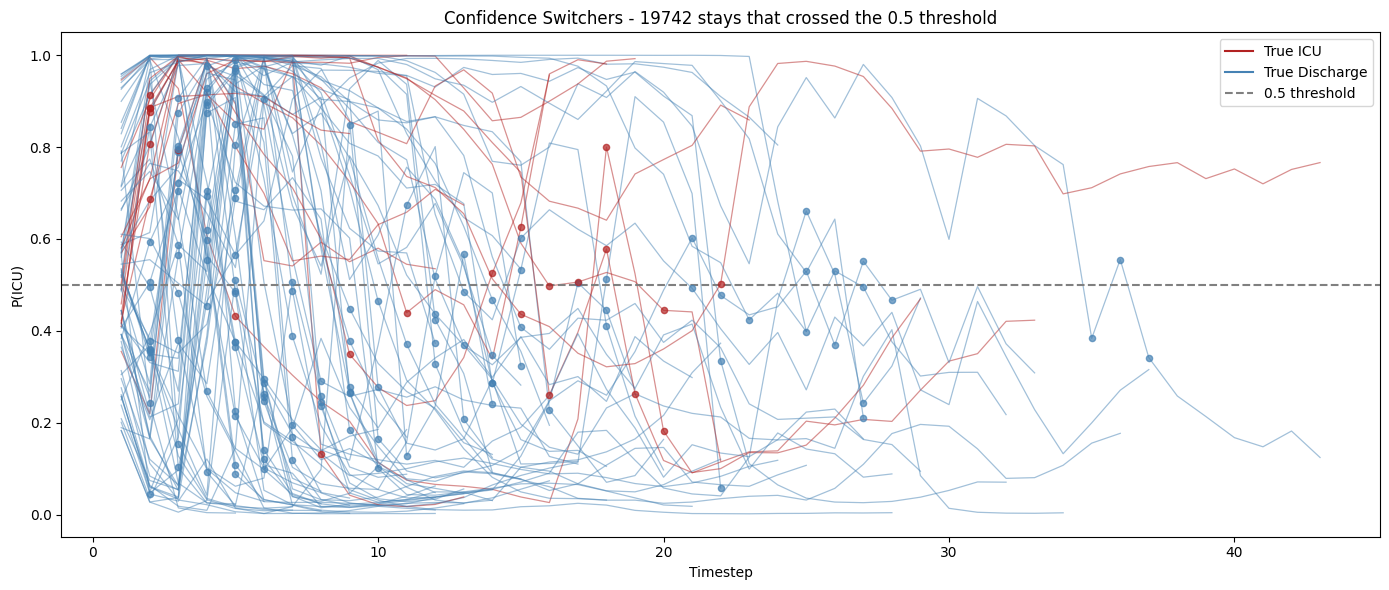

In [117]:
from matplotlib.lines import Line2D

picu_mat = sbs_seq_probs_all[:, :, 1].numpy().copy()
for i, L in enumerate(sbs_lengths_all.numpy()):
    picu_mat[i, int(L):] = float('nan')

discharge_mask = (sbs_true_labels == 0).numpy()
icu_mask = (sbs_true_labels == 1).numpy()

# ── Plot 1: Mean trajectories ──────────────────────────────────────────────
mean_dis = np.nanmean(picu_mat[discharge_mask], axis=0)
mean_icu = np.nanmean(picu_mat[icu_mask], axis=0)
ts = np.arange(1, picu_mat.shape[1] + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts, mean_dis, label='True Discharge', color='steelblue')
ax.plot(ts, mean_icu, label='True ICU', color='firebrick')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean P(ICU)')
ax.set_title('Mean Confidence Trajectory by True Outcome (SbS 40% split)')
ax.legend(); plt.tight_layout(); plt.show()

# ── Plot 2: Mean confidence by LOS bin ────────────────────────────────────
los_bins = [(1, 7), (8, 15), (16, 30), (31, int(sbs_lengths_all.max().item()))]
los_bin_labels = ['1-7 steps', '8-15 steps', '16-30 steps', '30+ steps']

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (lo, hi), lbl in zip(axes, los_bins, los_bin_labels):
    mask_len = ((sbs_lengths_all >= lo) & (sbs_lengths_all <= hi)).numpy()
    for outcome, color, name in [(0, 'steelblue', 'Discharge'), (1, 'firebrick', 'ICU')]:
        m = mask_len & (sbs_true_labels.numpy() == outcome)
        if m.sum() == 0:
            continue
        mean_t = np.nanmean(picu_mat[m], axis=0)
        ax.plot(np.arange(1, len(mean_t) + 1), mean_t, label=name, color=color)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(0, hi + 2); ax.set_ylim(0, 1)
    ax.set_title(lbl); ax.set_xlabel('Timestep')
axes[0].set_ylabel('Mean P(ICU)')
axes[0].legend(); plt.suptitle('Mean Confidence by LOS Bin', y=1.02)
plt.tight_layout(); plt.show()

# ── Plot 3: Individual stay traces ─────────────────────────────────────────
n_sample = 50
sample_idx = torch.randperm(len(sbs_true_labels), generator=torch.Generator().manual_seed(10))[:n_sample]

fig, ax = plt.subplots(figsize=(14, 6))
for i in sample_idx.numpy():
    L = int(sbs_lengths_all[i].item())
    color = 'firebrick' if sbs_true_labels[i] == 1 else 'steelblue'
    ax.plot(np.arange(1, L + 1), picu_mat[i, :L], alpha=0.4, linewidth=0.8, color=color)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
legend_elements = [
    Line2D([0], [0], color='firebrick',  lw=1.5, label='True ICU'),
    Line2D([0], [0], color='steelblue',  lw=1.5, label='True Discharge'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label='0.5 threshold'),
]
ax.set_xlabel('Timestep'); ax.set_ylabel('P(ICU)')
ax.set_title('Per-Stay Confidence Trajectories (sample of 50)')
ax.legend(handles=legend_elements); plt.tight_layout(); plt.show()

# ── Plot 4: Confidence switchers ───────────────────────────────────────────
# A switcher is a stay where P(ICU) crosses the 0.5 threshold at least once
switcher_idx = []
for i in range(len(sbs_true_labels)):
    L = int(sbs_lengths_all[i].item())
    if L < 2:
        continue
    above = picu_mat[i, :L] > 0.5
    if (np.diff(above.astype(int)) != 0).any():
        switcher_idx.append(i)

print(f"Confidence switchers: {len(switcher_idx)} / {len(sbs_true_labels)} stays "
      f"({len(switcher_idx)/len(sbs_true_labels):.1%})")

fig, ax = plt.subplots(figsize=(14, 6))
for i in switcher_idx[:80]:
    L = int(sbs_lengths_all[i].item())
    trace = picu_mat[i, :L]
    color = 'firebrick' if sbs_true_labels[i] == 1 else 'steelblue'
    ax.plot(np.arange(1, L + 1), trace, alpha=0.5, linewidth=0.9, color=color)
    above = trace > 0.5
    switches = np.where(np.diff(above.astype(int)) != 0)[0] + 1
    ax.scatter(switches + 1, trace[switches], color=color, s=20, zorder=5, alpha=0.7)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
legend_elements = [
    Line2D([0], [0], color='firebrick',  lw=1.5, label='True ICU'),
    Line2D([0], [0], color='steelblue',  lw=1.5, label='True Discharge'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label='0.5 threshold'),
]
ax.set_xlabel('Timestep'); ax.set_ylabel('P(ICU)')
ax.set_title(f"Confidence Switchers - {len(switcher_idx)} stays that crossed the 0.5 threshold")
ax.legend(handles=legend_elements); plt.tight_layout(); plt.show()


In [118]:
# Build long-form p_icu column aligned to df_sbs_infer rows
infer_stay_order = df_sbs_infer.drop_duplicates('ed_stay_id')['ed_stay_id'].values

p_icu_rows = []
for stay_pos, stay_id in enumerate(infer_stay_order):
    L = int(sbs_lengths_all[stay_pos].item())
    p_icu_trace = sbs_seq_probs_all[stay_pos, :L, 1].numpy()
    p_icu_rows.append(pd.DataFrame({
        'ed_stay_id': stay_id,
        'step_idx': np.arange(L),
        'p_icu': p_icu_trace,
    }))

p_icu_df = pd.concat(p_icu_rows, ignore_index=True)

# Assign step_idx within each stay (row order == timestep order)
df_sbs_infer = df_sbs_infer.copy()
df_sbs_infer['step_idx'] = df_sbs_infer.groupby('ed_stay_id').cumcount()

df_rl = df_sbs_infer.merge(p_icu_df, on=['ed_stay_id', 'step_idx'], how='left')

print(f"RL dataset shape: {df_rl.shape}")
print(f"NaN p_icu rows:   {df_rl['p_icu'].isna().sum()}")
print(df_rl[['ed_stay_id', 'step_idx', 'p_icu', 'terminal_event']].head(10))


RL dataset shape: (448737, 233)
NaN p_icu rows:   0
   ed_stay_id  step_idx     p_icu  terminal_event
0    30000177         0  0.840725  DISCHARGE_WARD
1    30000177         1  0.997999  DISCHARGE_WARD
2    30000177         2  0.999968  DISCHARGE_WARD
3    30000177         3  0.999974  DISCHARGE_WARD
4    30000177         4  0.999271  DISCHARGE_WARD
5    30000177         5  0.995912  DISCHARGE_WARD
6    30000177         6  0.985980  DISCHARGE_WARD
7    30000177         7  0.918160  DISCHARGE_WARD
8    30000177         8  0.739130  DISCHARGE_WARD
9    30000177         9  0.545657  DISCHARGE_WARD


In [ ]:
from datasets import Dataset

sbs_hf_repo = 'ADS599-Capstone/confidence_delta_lstm'

# Push model - PyTorchModelHubMixin uses safetensors by default
sbs_model.push_to_hub(
    sbs_hf_repo,
    commit_message='Add SbS LSTM model (60/40 split for RL confidence signal)',
)
print(f'Model pushed to {sbs_hf_repo}')

sbs_hf_repo = 'ADS599-Capstone/confidence_delta_data'
# Push RL dataset
hf_dataset = Dataset.from_pandas(df_rl.reset_index(drop=True))
hf_dataset.push_to_hub(sbs_hf_repo, split='rl_train')
print(f'RL dataset pushed to {sbs_hf_repo} (split=rl_train)')
print(f"  Stays: {df_rl['ed_stay_id'].nunique():,}")
print(f"  Rows:  {len(df_rl):,}")
print(f"  Cols:  {df_rl.shape[1]}")
